In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import pygraphviz as pgv
from nxpd import draw, nxpdParams
#from networkx.drawing.nx_agraph import graphviz_layout

nxpdParams['show'] = 'ipynb'
%matplotlib inline

# Global Measures

In [19]:
G = nx.erdos_renyi_graph(30, 0.11)

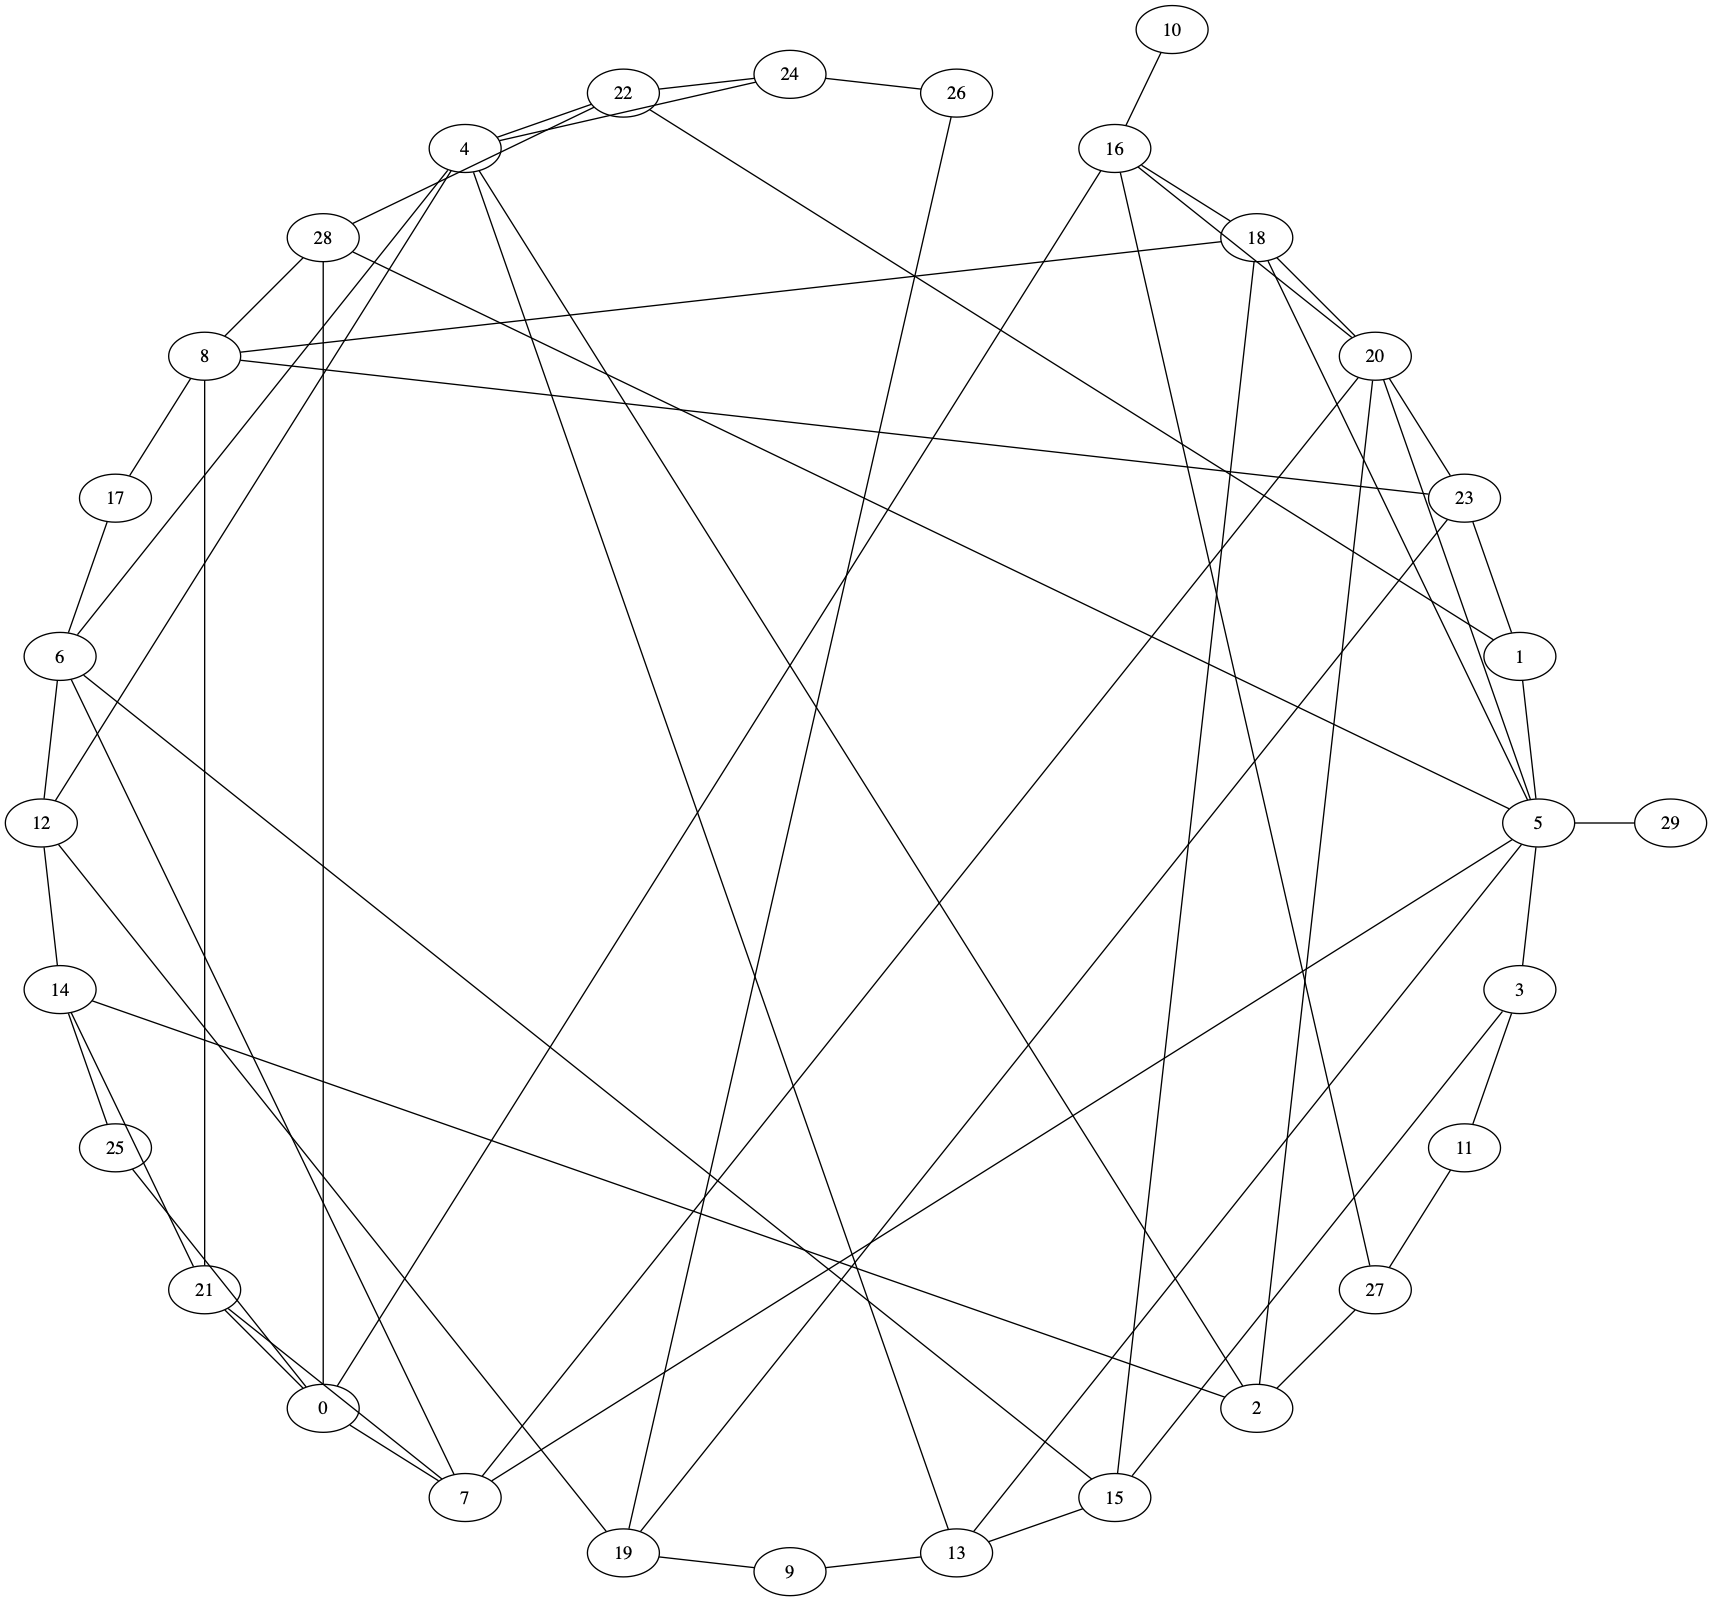

In [20]:
draw(G, layout='circo')

In [21]:
len(G)

30

In [22]:
len(G.nodes)

30

In [23]:
len(G.edges)

57

In [24]:
len(list(nx.non_edges(G)))

378

In [25]:
nx.density(G)

0.1310344827586207

In [26]:
ego = 21
alters1 = G[ego]
alters1

AtlasView({0: {}, 7: {}, 8: {}, 14: {}})

In [27]:
len(alters1)

4

In [28]:
alters2 = list(nx.all_neighbors(G, ego))
alters2

[0, 7, 8, 14]

In [29]:
len(alters2)

4

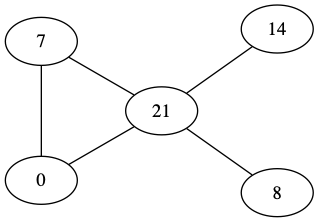

In [30]:
egonet = nx.ego_graph(G, ego)
draw(egonet, layout='circo')

In [31]:
clust_coef = nx.clustering(nx.Graph(G), ego)
clust_coef
# clustering here is a measure of "stariness"

0.16666666666666666

In [32]:
avg_cc = nx.average_clustering(nx.Graph(G))
avg_cc

0.0646031746031746

In [33]:
trans = nx.transitivity(G)
trans

0.09230769230769231

# Paths

In [34]:
path_gen = nx.shortest_simple_paths(G, ego, 'Agent Based Model')
#next(path_gen)

In [35]:
# measure of how close a node is to the center of the graph
ecc = nx.eccentricity(nx.Graph(G))
print(ecc[ego])

4


In [36]:
print(nx.diameter(G, ecc))

5


In [37]:
print(nx.radius(G, ecc))

3


# Centrality

In [38]:
nx.center(G, e=ecc)

[2, 20, 28]

In [39]:
nx.periphery(G, e=ecc)

[3, 9, 10, 11, 12, 19, 24, 26, 29]

In [40]:
dgr = nx.degree_centrality(G)
clo = nx.closeness_centrality(G)
har = nx.harmonic_centrality(G)
eig = nx.eigenvector_centrality(G)
bet = nx.betweenness_centrality(G)
pgr = nx.pagerank(G)
hits = nx.hits(G)

centralities = pd.concat(
    [pd.Series(c) 
     for c in (hits[1], eig, pgr, har, clo, hits[0], dgr, bet)],
    axis=1)
centralities.columns = (
    'Authorities', 'Eigenvector', 'PageRank', 'Harmonic', 'Closeness',
    'Hubs', 'Degree', 'Betweenness')
centralities['Harmonic'] /= centralities.shape[0]
centralities.head()

,Authorities,Eigenvector,PageRank,Harmonic,Closeness,Hubs,Degree,Betweenness
0,0.044857,0.218179,0.042053,0.475000,0.408451,0.044857,0.172414,0.076284
1,0.031514,0.153282,0.026691,0.438889,0.391892,0.031514,0.103448,0.024681
2,0.034784,0.169187,0.034502,0.483333,0.439394,0.034784,0.137931,0.090459
3,0.027389,0.133217,0.028374,0.420556,0.367089,0.027389,0.103448,0.040719
4,0.041736,0.203008,0.049573,0.519444,0.453125,0.041736,0.206897,0.125233


In [41]:
c_df = centralities.corr()
ll_triangle = np.tri(c_df.shape[0], k=-1)
c_df *= ll_triangle
c_series = c_df.stack().sort_values()
c_series.tail()

Closeness    Harmonic       0.988520
Degree       PageRank       0.995342
Hubs         Eigenvector    1.000000
Eigenvector  Authorities    1.000000
Hubs         Authorities    1.000000
dtype: float64

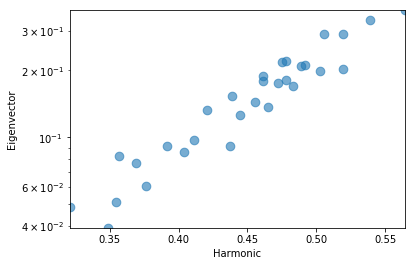

In [42]:
X = 'Harmonic'
Y = 'Eigenvector'
limits = pd.concat(
    [centralities[[X, Y]].min(), centralities[[X, Y]].max()], axis=1
).values
centralities.plot(kind='scatter', 
                  x=X,
                  y=Y, 
                  xlim=limits[0], 
                  ylim=limits[1], 
                  s=75, 
                  logy=True, 
                  alpha=0.6);

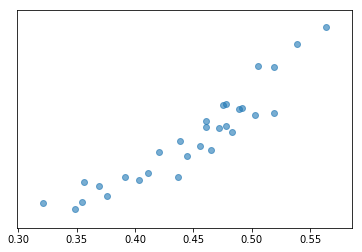

In [43]:
plt.scatter(centralities.Harmonic, centralities.Eigenvector + 1, alpha=0.6);
plt.yscale('log');

In [44]:
ego_degree, other_degree = zip(*nx.average_degree_connectivity(G).items())

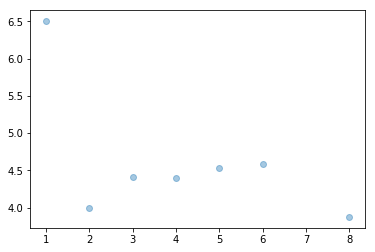

In [46]:
plt.scatter(ego_degree, other_degree, alpha=0.4);